In [1]:
# =========================================================
# Step 1: Import Required Libraries
# AffectNet 60:40 Experiment
# =========================================================

# Basic libraries
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Image processing
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Dataset & DataLoader
from torch.utils.data import Dataset, DataLoader

# TorchVision
from torchvision import transforms
from torchvision import models

# Training utilities
from tqdm import tqdm

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# Set Random Seed (for reproducibility)
# =========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# =========================================================
# Device
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [2]:
# =========================================================
# Step 2: Create Full AffectNet DataFrame
# =========================================================

import os
import pandas as pd

affectnet_root = "/kaggle/input/datasets/mstjebashazida/affectnet/archive (3)/Train"

# =========================================================
# Label Mapping
# =========================================================

label_map = {
    "anger": 0,
    "contempt": 1,
    "disgust": 2,
    "fear": 3,
    "happy": 4,
    "neutral": 5,
    "sad": 6,
    "surprise": 7
}

image_paths = []
labels = []

# =========================================================
# Read dataset
# =========================================================

for class_name in sorted(os.listdir(affectnet_root)):

    class_path = os.path.join(affectnet_root, class_name)

    if not os.path.isdir(class_path):
        continue

    label = label_map[class_name.lower()]

    for image_name in os.listdir(class_path):

        image_paths.append(os.path.join(class_path, image_name))
        labels.append(label)

# =========================================================
# Create DataFrame
# =========================================================

full_df_affect = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images in full AffectNet:", len(full_df_affect))

print("\nClass distribution:")
print(full_df_affect["label"].value_counts().sort_index())

print("\nFirst 5 rows:")
display(full_df_affect.head())

Total images in full AffectNet: 16108

Class distribution:
label
0    1500
1    1559
2    1229
3    1512
4    2340
5    2758
6    3091
7    2119
Name: count, dtype: int64

First 5 rows:


,image_path,label
0,/kaggle/input/datasets/mstjebashazida/affectne...,0
1,/kaggle/input/datasets/mstjebashazida/affectne...,0
2,/kaggle/input/datasets/mstjebashazida/affectne...,0
3,/kaggle/input/datasets/mstjebashazida/affectne...,0
4,/kaggle/input/datasets/mstjebashazida/affectne...,0


In [3]:
from sklearn.model_selection import train_test_split

# =========================================================
# Step 3: 60:40 Train-Test Split
# =========================================================

train_df_affect_60_40, test_df_affect_60_40 = train_test_split(
    full_df_affect,
    test_size=0.40,
    stratify=full_df_affect["label"],
    random_state=42
)

# Reset index
train_df_affect_60_40 = train_df_affect_60_40.reset_index(drop=True)
test_df_affect_60_40 = test_df_affect_60_40.reset_index(drop=True)

# =========================================================
# Display Information
# =========================================================

print("AffectNet 60:40 Train size:", len(train_df_affect_60_40))
print("AffectNet 60:40 Test size :", len(test_df_affect_60_40))

print("\nTrain class distribution:")
print(train_df_affect_60_40["label"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df_affect_60_40["label"].value_counts().sort_index())

AffectNet 60:40 Train size: 9664
AffectNet 60:40 Test size : 6444

Train class distribution:
label
0     900
1     935
2     737
3     907
4    1404
5    1655
6    1855
7    1271
Name: count, dtype: int64

Test class distribution:
label
0     600
1     624
2     492
3     605
4     936
5    1103
6    1236
7     848
Name: count, dtype: int64


In [4]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# =========================================================
# CNN Image Transform (96x96)
# =========================================================

train_transform_cnn_affect_60_40 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform_cnn_affect_60_40 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

# =========================================================
# Dataset Class
# =========================================================

class AffectNetDatasetCNN(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        image_path = self.dataframe.iloc[idx]["image_path"]
        label = int(self.dataframe.iloc[idx]["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================================================
# Create Dataset
# =========================================================

train_dataset_cnn_affect_60_40 = AffectNetDatasetCNN(
    train_df_affect_60_40,
    transform=train_transform_cnn_affect_60_40
)

test_dataset_cnn_affect_60_40 = AffectNetDatasetCNN(
    test_df_affect_60_40,
    transform=test_transform_cnn_affect_60_40
)

# =========================================================
# Create DataLoader
# =========================================================

train_loader_cnn_affect_60_40 = DataLoader(
    train_dataset_cnn_affect_60_40,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_cnn_affect_60_40 = DataLoader(
    test_dataset_cnn_affect_60_40,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# =========================================================
# Display Information
# =========================================================

print("CNN AffectNet 60:40 Train samples:", len(train_dataset_cnn_affect_60_40))
print("CNN AffectNet 60:40 Test samples :", len(test_dataset_cnn_affect_60_40))

CNN AffectNet 60:40 Train samples: 9664
CNN AffectNet 60:40 Test samples : 6444


In [5]:
import torch
import torch.nn as nn

# =========================================================
# Custom CNN Model
# =========================================================

class CustomCNN(nn.Module):

    def __init__(self, num_classes=8):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


# =========================================================
# Initialize Model
# =========================================================

cnn_model_affect_60_40 = CustomCNN(num_classes=8).to(device)

print(cnn_model_affect_60_40)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

In [6]:
import torch.optim as optim
import torch.nn as nn

# =========================================================
# Loss Function
# =========================================================

criterion_cnn_affect_60_40 = nn.CrossEntropyLoss()

# =========================================================
# Optimizer
# =========================================================

optimizer_cnn_affect_60_40 = optim.Adam(
    cnn_model_affect_60_40.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# =========================================================
# Learning Rate Scheduler
# =========================================================

scheduler_cnn_affect_60_40 = optim.lr_scheduler.StepLR(
    optimizer_cnn_affect_60_40,
    step_size=10,
    gamma=0.1
)

# =========================================================
# Display Configuration
# =========================================================

print("Loss Function :", criterion_cnn_affect_60_40)
print("Optimizer     :", optimizer_cnn_affect_60_40)
print("Scheduler     :", scheduler_cnn_affect_60_40)

Loss Function : CrossEntropyLoss()
Optimizer     : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler     : <torch.optim.lr_scheduler.StepLR object at 0x7cfaa10a21e0>


In [7]:
print("tihs")

tihs


In [8]:
from tqdm import tqdm
import copy
import os
import torch

# =========================================================
# Training settings
# =========================================================
num_epochs_cnn_affect_60_40 = 80
patience_cnn_affect_60_40 = 10

best_acc_cnn_affect_60_40 = 0.0
best_model_wts_cnn_affect_60_40 = copy.deepcopy(cnn_model_affect_60_40.state_dict())
epochs_no_improve_cnn_affect_60_40 = 0

train_acc_history_cnn_affect_60_40 = []
test_acc_history_cnn_affect_60_40 = []
train_loss_history_cnn_affect_60_40 = []
test_loss_history_cnn_affect_60_40 = []

# =========================================================
# Training Loop
# =========================================================
for epoch in range(num_epochs_cnn_affect_60_40):

    print(f"\nEpoch {epoch+1}/{num_epochs_cnn_affect_60_40}")

    # =====================================================
    # Train
    # =====================================================
    cnn_model_affect_60_40.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader_cnn_affect_60_40):

        images = images.to(device)
        labels = labels.to(device)

        optimizer_cnn_affect_60_40.zero_grad()

        outputs = cnn_model_affect_60_40(images)

        loss = criterion_cnn_affect_60_40(outputs, labels)

        loss.backward()

        optimizer_cnn_affect_60_40.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    # =====================================================
    # Validation
    # =====================================================
    cnn_model_affect_60_40.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(test_loader_cnn_affect_60_40):

            images = images.to(device)
            labels = labels.to(device)

            outputs = cnn_model_affect_60_40(images)

            loss = criterion_cnn_affect_60_40(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_loss = running_loss / total
    test_acc = 100 * correct / total

    scheduler_cnn_affect_60_40.step()

    train_loss_history_cnn_affect_60_40.append(train_loss)
    test_loss_history_cnn_affect_60_40.append(test_loss)

    train_acc_history_cnn_affect_60_40.append(train_acc)
    test_acc_history_cnn_affect_60_40.append(test_acc)

    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Test Acc  : {test_acc:.2f}%")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Test Loss : {test_loss:.4f}")

    # =====================================================
    # Save Best Model
    # =====================================================
    if test_acc > best_acc_cnn_affect_60_40:

        best_acc_cnn_affect_60_40 = test_acc
        best_model_wts_cnn_affect_60_40 = copy.deepcopy(
            cnn_model_affect_60_40.state_dict()
        )

        epochs_no_improve_cnn_affect_60_40 = 0

    else:

        epochs_no_improve_cnn_affect_60_40 += 1

    # =====================================================
    # Early Stopping
    # =====================================================
    if epochs_no_improve_cnn_affect_60_40 >= patience_cnn_affect_60_40:

        print("\nEarly stopping triggered.")
        break

# =========================================================
# Load Best Model
# =========================================================
cnn_model_affect_60_40.load_state_dict(best_model_wts_cnn_affect_60_40)

# =========================================================
# Save Model
# =========================================================
cnn_model_save_path_60_40 = "/kaggle/working/best_cnn_affectnet_60_40.pth"

torch.save(
    cnn_model_affect_60_40.state_dict(),
    cnn_model_save_path_60_40
)

# =========================================================
# Verify Save
# =========================================================
print("\nBest CNN AffectNet 60:40 Test Accuracy:", best_acc_cnn_affect_60_40)

print("Saved model:", cnn_model_save_path_60_40)

print("File exists after save? ->", os.path.exists(cnn_model_save_path_60_40))

print("Files currently in /kaggle/working:")
print(os.listdir("/kaggle/working"))


Epoch 1/80


100%|██████████| 101/101 [00:42<00:00,  2.39it/s]


Train Acc : 18.12%
Test Acc  : 28.93%
Train Loss: 2.1051
Test Loss : 1.8874

Epoch 2/80


100%|██████████| 101/101 [00:09<00:00, 11.09it/s]


Train Acc : 31.42%
Test Acc  : 33.81%
Train Loss: 1.6366
Test Loss : 1.4906

Epoch 3/80


...

Train Acc : 49.50%
Test Acc  : 52.76%
Train Loss: 1.2464
Test Loss : 1.1833

Epoch 31/80


100%|██████████| 101/101 [00:08<00:00, 12.35it/s]


Train Acc : 49.99%
Test Acc  : 52.73%
Train Loss: 1.2442
Test Loss : 1.1838

Epoch 32/80


100%|██████████| 101/101 [00:08<00:00, 12.23it/s]


Train Acc : 49.83%
Test Acc  : 52.76%
Train Loss: 1.2450
Test Loss : 1.1834

Early stopping triggered.

Best CNN AffectNet 60:40 Test Accuracy: 52.85536933581626
Saved model: /kaggle/working/best_cnn_affectnet_60_40.pth
File exists after save? -> True
Files currently in /kaggle/working:
['.virtual_documents', 'best_cnn_affectnet_60_40.pth']


In [9]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

# =========================================================
# Load Best Saved Model
# =========================================================

cnn_model_affect_60_40.load_state_dict(
    torch.load(
        "/kaggle/working/best_cnn_affectnet_60_40.pth",
        map_location=device
    )
)

cnn_model_affect_60_40.eval()

# =========================================================
# Prediction Lists
# =========================================================

cnn_probs_affect_60_40 = []
cnn_preds_affect_60_40 = []
cnn_true_affect_60_40 = []

# =========================================================
# Evaluation
# =========================================================

with torch.no_grad():

    for images, labels in test_loader_cnn_affect_60_40:

        images = images.to(device)

        outputs = cnn_model_affect_60_40(images)

        probs = F.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        cnn_probs_affect_60_40.extend(
            probs.cpu().numpy()
        )

        cnn_preds_affect_60_40.extend(
            preds.cpu().numpy()
        )

        cnn_true_affect_60_40.extend(
            labels.numpy()
        )

# =========================================================
# Convert to NumPy
# =========================================================

cnn_probs_affect_60_40 = np.array(cnn_probs_affect_60_40)
cnn_preds_affect_60_40 = np.array(cnn_preds_affect_60_40)
cnn_true_affect_60_40 = np.array(cnn_true_affect_60_40)

# =========================================================
# Accuracy
# =========================================================

cnn_acc_affect_60_40 = accuracy_score(
    cnn_true_affect_60_40,
    cnn_preds_affect_60_40
) * 100

print("CNN AffectNet 60:40 probabilities shape :", cnn_probs_affect_60_40.shape)
print("CNN AffectNet 60:40 predictions shape   :", cnn_preds_affect_60_40.shape)
print("CNN AffectNet 60:40 true labels shape   :", cnn_true_affect_60_40.shape)

print(f"\nCNN AffectNet 60:40 Accuracy from saved model: {cnn_acc_affect_60_40:.2f}%")

CNN AffectNet 60:40 probabilities shape : (6444, 8)
CNN AffectNet 60:40 predictions shape   : (6444,)
CNN AffectNet 60:40 true labels shape   : (6444,)

CNN AffectNet 60:40 Accuracy from saved model: 52.86%


In [10]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# =========================================================
# ResNet50 Image Transforms (96x96)
# =========================================================

train_transform_resnet_affect_60_40 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform_resnet_affect_60_40 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

# =========================================================
# Dataset Class
# =========================================================

class AffectNetDatasetResNet(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        image_path = self.dataframe.iloc[idx]["image_path"]
        label = int(self.dataframe.iloc[idx]["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================================================
# Create Dataset
# =========================================================

train_dataset_resnet_affect_60_40 = AffectNetDatasetResNet(
    train_df_affect_60_40,
    transform=train_transform_resnet_affect_60_40
)

test_dataset_resnet_affect_60_40 = AffectNetDatasetResNet(
    test_df_affect_60_40,
    transform=test_transform_resnet_affect_60_40
)

# =========================================================
# DataLoaders
# =========================================================

train_loader_resnet_affect_60_40 = DataLoader(
    train_dataset_resnet_affect_60_40,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_resnet_affect_60_40 = DataLoader(
    test_dataset_resnet_affect_60_40,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# =========================================================
# Display Information
# =========================================================

print("ResNet AffectNet 60:40 Train samples:", len(train_dataset_resnet_affect_60_40))
print("ResNet AffectNet 60:40 Test samples :", len(test_dataset_resnet_affect_60_40))

ResNet AffectNet 60:40 Train samples: 9664
ResNet AffectNet 60:40 Test samples : 6444


In [11]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# =========================================================
# ResNet50 Image Transforms (96x96)
# =========================================================

train_transform_resnet_affect_60_40 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform_resnet_affect_60_40 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

# =========================================================
# Dataset Class
# =========================================================

class AffectNetDatasetResNet(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        image_path = self.dataframe.iloc[idx]["image_path"]
        label = int(self.dataframe.iloc[idx]["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================================================
# Create Dataset
# =========================================================

train_dataset_resnet_affect_60_40 = AffectNetDatasetResNet(
    train_df_affect_60_40,
    transform=train_transform_resnet_affect_60_40
)

test_dataset_resnet_affect_60_40 = AffectNetDatasetResNet(
    test_df_affect_60_40,
    transform=test_transform_resnet_affect_60_40
)

# =========================================================
# DataLoaders
# =========================================================

train_loader_resnet_affect_60_40 = DataLoader(
    train_dataset_resnet_affect_60_40,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_resnet_affect_60_40 = DataLoader(
    test_dataset_resnet_affect_60_40,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# =========================================================
# Display Information
# =========================================================

print("ResNet AffectNet 60:40 Train samples:", len(train_dataset_resnet_affect_60_40))
print("ResNet AffectNet 60:40 Test samples :", len(test_dataset_resnet_affect_60_40))

ResNet AffectNet 60:40 Train samples: 9664
ResNet AffectNet 60:40 Test samples : 6444


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================================================
# Bottleneck Block
# =========================================================

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super(Bottleneck, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(
            out_channels,
            out_channels * self.expansion,
            kernel_size=1,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):

        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        out += self.shortcut(x)
        out = F.relu(out)

        return out

In [16]:
# =========================================================
# ResNet50 from Scratch
# =========================================================

class ResNet50Scratch(nn.Module):

    def __init__(self, num_classes=8):
        super(ResNet50Scratch, self).__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)

        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        self.layer1 = self._make_layer(64, 3, stride=1)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(512 * Bottleneck.expansion, num_classes)

    def _make_layer(self, out_channels, blocks, stride):

        layers = []

        layers.append(
            Bottleneck(
                self.in_channels,
                out_channels,
                stride
            )
        )

        self.in_channels = out_channels * Bottleneck.expansion

        for _ in range(1, blocks):
            layers.append(
                Bottleneck(
                    self.in_channels,
                    out_channels
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):

        x = F.relu(self.bn1(self.conv1(x)))

        x = self.maxpool(x)

        x = self.layer1(x)

        x = self.layer2(x)

        x = self.layer3(x)

        x = self.layer4(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.dropout(x)

        x = self.fc(x)

        return x

In [17]:
import torch.nn as nn
import torch.optim as optim

# =========================================================
# Initialize ResNet50 Model
# =========================================================

resnet_model_affect_60_40 = ResNet50Scratch(num_classes=8).to(device)

# =========================================================
# Loss Function
# =========================================================

criterion_resnet_affect_60_40 = nn.CrossEntropyLoss()

# =========================================================
# Optimizer
# =========================================================

optimizer_resnet_affect_60_40 = optim.Adam(
    resnet_model_affect_60_40.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# =========================================================
# Learning Rate Scheduler
# =========================================================

scheduler_resnet_affect_60_40 = optim.lr_scheduler.StepLR(
    optimizer_resnet_affect_60_40,
    step_size=10,
    gamma=0.1
)

# =========================================================
# Display Model
# =========================================================

print(resnet_model_affect_60_40)

print("\nLoss Function :", criterion_resnet_affect_60_40)
print("Optimizer     :", optimizer_resnet_affect_60_40)
print("Scheduler     :", scheduler_resnet_affect_60_40)

ResNet50Scratch(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05

In [18]:
from tqdm import tqdm
import copy
import os

# =========================================================
# Training Settings
# =========================================================

num_epochs_resnet_affect_60_40 = 80
patience_resnet_affect_60_40 = 10

best_acc_resnet_affect_60_40 = 0.0
best_model_wts_resnet_affect_60_40 = copy.deepcopy(
    resnet_model_affect_60_40.state_dict()
)

epochs_no_improve_resnet_affect_60_40 = 0

train_acc_history_resnet_affect_60_40 = []
test_acc_history_resnet_affect_60_40 = []

train_loss_history_resnet_affect_60_40 = []
test_loss_history_resnet_affect_60_40 = []

# =========================================================
# Training Loop
# =========================================================

for epoch in range(num_epochs_resnet_affect_60_40):

    print(f"\nEpoch {epoch+1}/{num_epochs_resnet_affect_60_40}")

    # -----------------------------
    # Train
    # -----------------------------
    resnet_model_affect_60_40.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader_resnet_affect_60_40):

        images = images.to(device)
        labels = labels.to(device)

        optimizer_resnet_affect_60_40.zero_grad()

        outputs = resnet_model_affect_60_40(images)

        loss = criterion_resnet_affect_60_40(outputs, labels)

        loss.backward()

        optimizer_resnet_affect_60_40.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    # -----------------------------
    # Validation
    # -----------------------------
    resnet_model_affect_60_40.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(test_loader_resnet_affect_60_40):

            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet_model_affect_60_40(images)

            loss = criterion_resnet_affect_60_40(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    test_loss = running_loss / total
    test_acc = 100 * correct / total

    scheduler_resnet_affect_60_40.step()

    train_loss_history_resnet_affect_60_40.append(train_loss)
    test_loss_history_resnet_affect_60_40.append(test_loss)

    train_acc_history_resnet_affect_60_40.append(train_acc)
    test_acc_history_resnet_affect_60_40.append(test_acc)

    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Test Acc  : {test_acc:.2f}%")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Test Loss : {test_loss:.4f}")

    # -----------------------------
    # Save Best Model
    # -----------------------------
    if test_acc > best_acc_resnet_affect_60_40:

        best_acc_resnet_affect_60_40 = test_acc

        best_model_wts_resnet_affect_60_40 = copy.deepcopy(
            resnet_model_affect_60_40.state_dict()
        )

        epochs_no_improve_resnet_affect_60_40 = 0

    else:

        epochs_no_improve_resnet_affect_60_40 += 1

    # -----------------------------
    # Early Stopping
    # -----------------------------
    if epochs_no_improve_resnet_affect_60_40 >= patience_resnet_affect_60_40:

        print("\nEarly stopping triggered")
        break

# =========================================================
# Load Best Weights
# =========================================================

resnet_model_affect_60_40.load_state_dict(
    best_model_wts_resnet_affect_60_40
)

# =========================================================
# Save Best Model
# =========================================================

resnet_model_save_path_60_40 = "/kaggle/working/best_resnet50_affectnet_60_40.pth"

torch.save(
    resnet_model_affect_60_40.state_dict(),
    resnet_model_save_path_60_40
)

# =========================================================
# Verify Save
# =========================================================

print("\nBest ResNet50 AffectNet 60:40 Test Accuracy:",
      best_acc_resnet_affect_60_40)

print("Saved model:", resnet_model_save_path_60_40)

print("File exists after save? ->",
      os.path.exists(resnet_model_save_path_60_40))

print("Files currently in /kaggle/working:")

print(os.listdir("/kaggle/working"))


Epoch 1/80


100%|██████████| 101/101 [00:10<00:00,  9.71it/s]


Train Acc : 29.18%
Test Acc  : 35.97%
Train Loss: 1.9855
Test Loss : 5.7209

Epoch 2/80


100%|██████████| 101/101 [00:08<00:00, 11.88it/s]


Train Acc : 41.03%
Test Acc  : 42.49%
Train Loss: 1.5170
Test Loss : 1.5300

Epoch 3/80


...

Train Acc : 77.50%
Test Acc  : 63.97%
Train Loss: 0.6164
Test Loss : 1.0528

Epoch 31/80


100%|██████████| 101/101 [00:07<00:00, 13.00it/s]


Train Acc : 77.84%
Test Acc  : 64.03%
Train Loss: 0.6048
Test Loss : 1.0532

Epoch 32/80


100%|██████████| 101/101 [00:07<00:00, 12.88it/s]


Train Acc : 77.84%
Test Acc  : 63.89%
Train Loss: 0.6010
Test Loss : 1.0609

Early stopping triggered

Best ResNet50 AffectNet 60:40 Test Accuracy: 64.69584109248913
Saved model: /kaggle/working/best_resnet50_affectnet_60_40.pth
File exists after save? -> True
Files currently in /kaggle/working:
['.virtual_documents', 'best_cnn_affectnet_60_40.pth', 'best_resnet50_affectnet_60_40.pth']


In [19]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

# =========================================================
# Load Best Saved Model
# =========================================================

resnet_model_affect_60_40.load_state_dict(
    torch.load(
        "/kaggle/working/best_resnet50_affectnet_60_40.pth",
        map_location=device
    )
)

resnet_model_affect_60_40.eval()

# =========================================================
# Prediction Lists
# =========================================================

resnet_probs_affect_60_40 = []
resnet_preds_affect_60_40 = []
resnet_true_affect_60_40 = []

# =========================================================
# Evaluation
# =========================================================

with torch.no_grad():

    for images, labels in test_loader_resnet_affect_60_40:

        images = images.to(device)

        outputs = resnet_model_affect_60_40(images)

        probs = F.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        resnet_probs_affect_60_40.extend(
            probs.cpu().numpy()
        )

        resnet_preds_affect_60_40.extend(
            preds.cpu().numpy()
        )

        resnet_true_affect_60_40.extend(
            labels.numpy()
        )

# =========================================================
# Convert to NumPy
# =========================================================

resnet_probs_affect_60_40 = np.array(resnet_probs_affect_60_40)

resnet_preds_affect_60_40 = np.array(resnet_preds_affect_60_40)

resnet_true_affect_60_40 = np.array(resnet_true_affect_60_40)

# =========================================================
# Accuracy
# =========================================================

resnet_acc_affect_60_40 = accuracy_score(
    resnet_true_affect_60_40,
    resnet_preds_affect_60_40
) * 100

# =========================================================
# Display Results
# =========================================================

print("ResNet50 AffectNet 60:40 probabilities shape :", resnet_probs_affect_60_40.shape)
print("ResNet50 AffectNet 60:40 predictions shape   :", resnet_preds_affect_60_40.shape)
print("AffectNet 60:40 true labels shape            :", resnet_true_affect_60_40.shape)

print(f"\nResNet50 AffectNet 60:40 Accuracy from saved model: {resnet_acc_affect_60_40:.2f}%")

ResNet50 AffectNet 60:40 probabilities shape : (6444, 8)
ResNet50 AffectNet 60:40 predictions shape   : (6444,)
AffectNet 60:40 true labels shape            : (6444,)

ResNet50 AffectNet 60:40 Accuracy from saved model: 64.70%


In [20]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# =========================================================
# EfficientNet Image Transforms (224x224)
# =========================================================

train_transform_eff_affect_60_40 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform_eff_affect_60_40 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================================================
# Dataset Class
# =========================================================

class AffectNetDatasetEfficientNet(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        image_path = self.dataframe.iloc[idx]["image_path"]
        label = int(self.dataframe.iloc[idx]["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================================================
# Create Dataset
# =========================================================

train_dataset_eff_affect_60_40 = AffectNetDatasetEfficientNet(
    train_df_affect_60_40,
    transform=train_transform_eff_affect_60_40
)

test_dataset_eff_affect_60_40 = AffectNetDatasetEfficientNet(
    test_df_affect_60_40,
    transform=test_transform_eff_affect_60_40
)

# =========================================================
# DataLoaders
# =========================================================

train_loader_eff_affect_60_40 = DataLoader(
    train_dataset_eff_affect_60_40,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_eff_affect_60_40 = DataLoader(
    test_dataset_eff_affect_60_40,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# =========================================================
# Display Information
# =========================================================

print("EfficientNet AffectNet 60:40 Train samples:", len(train_dataset_eff_affect_60_40))
print("EfficientNet AffectNet 60:40 Test samples :", len(test_dataset_eff_affect_60_40))

EfficientNet AffectNet 60:40 Train samples: 9664
EfficientNet AffectNet 60:40 Test samples : 6444


In [22]:
import torch
import torch.nn as nn
from torchvision import models

# =========================================================
# Improved EfficientNet-B0
# =========================================================

class ImprovedEfficientNet(nn.Module):

    def __init__(self, num_classes=8):
        super(ImprovedEfficientNet, self).__init__()

        # EfficientNet-B0 backbone (no pretrained weights)
        self.backbone = models.efficientnet_b0(weights=None)

        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

In [23]:
import torch.nn as nn
import torch.optim as optim

# =========================================================
# Initialize Improved EfficientNet
# =========================================================

efficientnet_model_affect_60_40 = ImprovedEfficientNet(
    num_classes=8
).to(device)

# =========================================================
# Loss Function
# =========================================================

criterion_efficientnet_affect_60_40 = nn.CrossEntropyLoss()

# =========================================================
# Optimizer
# =========================================================

optimizer_efficientnet_affect_60_40 = optim.Adam(
    efficientnet_model_affect_60_40.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# =========================================================
# Learning Rate Scheduler
# =========================================================

scheduler_efficientnet_affect_60_40 = optim.lr_scheduler.StepLR(
    optimizer_efficientnet_affect_60_40,
    step_size=10,
    gamma=0.1
)

# =========================================================
# Display Model
# =========================================================

print(efficientnet_model_affect_60_40)

print("\nLoss Function :", criterion_efficientnet_affect_60_40)
print("Optimizer     :", optimizer_efficientnet_affect_60_40)
print("Scheduler     :", scheduler_efficientnet_affect_60_40)

ImprovedEfficientNet(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
            

In [24]:
import torch.nn as nn
import torch.optim as optim

# =========================================================
# Initialize Improved EfficientNet
# =========================================================

efficientnet_model_affect_60_40 = ImprovedEfficientNet(
    num_classes=8
).to(device)

# =========================================================
# Loss Function
# =========================================================

criterion_efficientnet_affect_60_40 = nn.CrossEntropyLoss()

# =========================================================
# Optimizer
# =========================================================

optimizer_efficientnet_affect_60_40 = optim.Adam(
    efficientnet_model_affect_60_40.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# =========================================================
# Learning Rate Scheduler
# =========================================================

scheduler_efficientnet_affect_60_40 = optim.lr_scheduler.StepLR(
    optimizer_efficientnet_affect_60_40,
    step_size=10,
    gamma=0.1
)

# =========================================================
# Display Model
# =========================================================

print(efficientnet_model_affect_60_40)

print("\nLoss Function :", criterion_efficientnet_affect_60_40)
print("Optimizer     :", optimizer_efficientnet_affect_60_40)
print("Scheduler     :", scheduler_efficientnet_affect_60_40)

ImprovedEfficientNet(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
            

In [25]:
from tqdm import tqdm
import copy
import os

# =========================================================
# Training Settings
# =========================================================

num_epochs_efficientnet_affect_60_40 = 80
patience_efficientnet_affect_60_40 = 10

best_acc_efficientnet_affect_60_40 = 0.0
best_model_wts_efficientnet_affect_60_40 = copy.deepcopy(
    efficientnet_model_affect_60_40.state_dict()
)

epochs_no_improve_efficientnet_affect_60_40 = 0

train_acc_history_efficientnet_affect_60_40 = []
test_acc_history_efficientnet_affect_60_40 = []

train_loss_history_efficientnet_affect_60_40 = []
test_loss_history_efficientnet_affect_60_40 = []

# =========================================================
# Training Loop
# =========================================================

for epoch in range(num_epochs_efficientnet_affect_60_40):

    print(f"\nEpoch {epoch+1}/{num_epochs_efficientnet_affect_60_40}")

    # -------------------------------------------------
    # Train
    # -------------------------------------------------

    efficientnet_model_affect_60_40.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader_eff_affect_60_40):

        images = images.to(device)
        labels = labels.to(device)

        optimizer_efficientnet_affect_60_40.zero_grad()

        outputs = efficientnet_model_affect_60_40(images)

        loss = criterion_efficientnet_affect_60_40(outputs, labels)

        loss.backward()

        optimizer_efficientnet_affect_60_40.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    # -------------------------------------------------
    # Validation
    # -------------------------------------------------

    efficientnet_model_affect_60_40.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(test_loader_eff_affect_60_40):

            images = images.to(device)
            labels = labels.to(device)

            outputs = efficientnet_model_affect_60_40(images)

            loss = criterion_efficientnet_affect_60_40(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_loss = running_loss / total
    test_acc = 100 * correct / total

    scheduler_efficientnet_affect_60_40.step()

    train_loss_history_efficientnet_affect_60_40.append(train_loss)
    test_loss_history_efficientnet_affect_60_40.append(test_loss)

    train_acc_history_efficientnet_affect_60_40.append(train_acc)
    test_acc_history_efficientnet_affect_60_40.append(test_acc)

    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Test Acc  : {test_acc:.2f}%")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Test Loss : {test_loss:.4f}")

    # -------------------------------------------------
    # Save Best Model
    # -------------------------------------------------

    if test_acc > best_acc_efficientnet_affect_60_40:

        best_acc_efficientnet_affect_60_40 = test_acc

        best_model_wts_efficientnet_affect_60_40 = copy.deepcopy(
            efficientnet_model_affect_60_40.state_dict()
        )

        epochs_no_improve_efficientnet_affect_60_40 = 0

    else:

        epochs_no_improve_efficientnet_affect_60_40 += 1

    # -------------------------------------------------
    # Early Stopping
    # -------------------------------------------------

    if epochs_no_improve_efficientnet_affect_60_40 >= patience_efficientnet_affect_60_40:

        print("\nEarly stopping triggered")
        break

# =========================================================
# Load Best Weights
# =========================================================

efficientnet_model_affect_60_40.load_state_dict(
    best_model_wts_efficientnet_affect_60_40
)

# =========================================================
# Save Best Model
# =========================================================

efficientnet_model_save_path_60_40 = "/kaggle/working/best_efficientnet_affectnet_60_40.pth"

torch.save(
    efficientnet_model_affect_60_40.state_dict(),
    efficientnet_model_save_path_60_40
)

# =========================================================
# Verify Save
# =========================================================

print("\nBest Improved EfficientNet AffectNet 60:40 Test Accuracy:",
      best_acc_efficientnet_affect_60_40)

print("Saved model:", efficientnet_model_save_path_60_40)

print("File exists after save? ->",
      os.path.exists(efficientnet_model_save_path_60_40))

print("Files currently in /kaggle/working:")

print(os.listdir("/kaggle/working"))


Epoch 1/80


100%|██████████| 202/202 [00:15<00:00, 13.08it/s]


Train Acc : 16.19%
Test Acc  : 19.62%
Train Loss: 2.1661
Test Loss : 2.1184

Epoch 2/80


100%|██████████| 202/202 [00:13<00:00, 14.97it/s]


Train Acc : 19.27%
Test Acc  : 24.81%
Train Loss: 2.0901
Test Loss : 2.0866

Epoch 3/80


...

Train Acc : 63.41%
Test Acc  : 60.34%
Train Loss: 0.9627
Test Loss : 1.1464

Epoch 44/80


100%|██████████| 202/202 [00:13<00:00, 15.15it/s]


Train Acc : 63.36%
Test Acc  : 60.66%
Train Loss: 0.9537
Test Loss : 1.0754

Epoch 45/80


100%|██████████| 202/202 [00:13<00:00, 15.17it/s]


Train Acc : 63.60%
Test Acc  : 60.40%
Train Loss: 0.9604
Test Loss : 1.0675

Early stopping triggered

Best Improved EfficientNet AffectNet 60:40 Test Accuracy: 60.81626319056487
Saved model: /kaggle/working/best_efficientnet_affectnet_60_40.pth
File exists after save? -> True
Files currently in /kaggle/working:
['.virtual_documents', 'best_cnn_affectnet_60_40.pth', 'best_resnet50_affectnet_60_40.pth', 'best_efficientnet_affectnet_60_40.pth']


In [26]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

# =========================================================
# Load Best Saved Model
# =========================================================

efficientnet_model_affect_60_40.load_state_dict(
    torch.load(
        "/kaggle/working/best_efficientnet_affectnet_60_40.pth",
        map_location=device
    )
)

efficientnet_model_affect_60_40.eval()

# =========================================================
# Prediction Lists
# =========================================================

efficient_probs_affect_60_40 = []
efficient_preds_affect_60_40 = []
efficient_true_affect_60_40 = []

# =========================================================
# Evaluation
# =========================================================

with torch.no_grad():

    for images, labels in test_loader_eff_affect_60_40:

        images = images.to(device)

        outputs = efficientnet_model_affect_60_40(images)

        probs = F.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        efficient_probs_affect_60_40.extend(
            probs.cpu().numpy()
        )

        efficient_preds_affect_60_40.extend(
            preds.cpu().numpy()
        )

        efficient_true_affect_60_40.extend(
            labels.numpy()
        )

# =========================================================
# Convert to NumPy
# =========================================================

efficient_probs_affect_60_40 = np.array(efficient_probs_affect_60_40)

efficient_preds_affect_60_40 = np.array(efficient_preds_affect_60_40)

efficient_true_affect_60_40 = np.array(efficient_true_affect_60_40)

# =========================================================
# Accuracy
# =========================================================

efficient_acc_affect_60_40 = accuracy_score(
    efficient_true_affect_60_40,
    efficient_preds_affect_60_40
) * 100

# =========================================================
# Display Results
# =========================================================

print("Improved EfficientNet AffectNet 60:40 probabilities shape :", efficient_probs_affect_60_40.shape)
print("Improved EfficientNet AffectNet 60:40 predictions shape   :", efficient_preds_affect_60_40.shape)
print("AffectNet 60:40 true labels shape                         :", efficient_true_affect_60_40.shape)

print(f"\nImproved EfficientNet AffectNet 60:40 Accuracy from saved model: {efficient_acc_affect_60_40:.2f}%")

Improved EfficientNet AffectNet 60:40 probabilities shape : (6444, 8)
Improved EfficientNet AffectNet 60:40 predictions shape   : (6444,)
AffectNet 60:40 true labels shape                         : (6444,)

Improved EfficientNet AffectNet 60:40 Accuracy from saved model: 60.82%


In [28]:
import numpy as np
from sklearn.metrics import accuracy_score

# =========================================================
# Convert Softmax Probabilities to Mass Functions
# =========================================================

def probs_to_mass(probs):
    """
    Convert softmax probabilities into DST mass function.
    """
    return probs / probs.sum(axis=1, keepdims=True)

# =========================================================
# DST Combination of Two Models
# =========================================================

def dst_combine_two(m1, m2):

    combined = m1 * m2

    combined = combined / combined.sum(axis=1, keepdims=True)

    return combined

# =========================================================
# DST Combination of Three Models
# =========================================================

def dst_combine_three(m1, m2, m3):

    temp = dst_combine_two(m1, m2)

    final = dst_combine_two(temp, m3)

    return final

# =========================================================
# CNN + ResNet50
# =========================================================

cnn_resnet_dst = dst_combine_two(
    probs_to_mass(cnn_probs_affect_60_40),
    probs_to_mass(resnet_probs_affect_60_40)
)

cnn_resnet_pred = np.argmax(cnn_resnet_dst, axis=1)

cnn_resnet_acc = accuracy_score(
    cnn_true_affect_60_40,
    cnn_resnet_pred
) * 100

# =========================================================
# CNN + EfficientNet
# =========================================================

cnn_eff_dst = dst_combine_two(
    probs_to_mass(cnn_probs_affect_60_40),
    probs_to_mass(efficient_probs_affect_60_40)
)

cnn_eff_pred = np.argmax(cnn_eff_dst, axis=1)

cnn_eff_acc = accuracy_score(
    cnn_true_affect_60_40,
    cnn_eff_pred
) * 100

# =========================================================
# ResNet50 + EfficientNet
# =========================================================

resnet_eff_dst = dst_combine_two(
    probs_to_mass(resnet_probs_affect_60_40),
    probs_to_mass(efficient_probs_affect_60_40)
)

resnet_eff_pred = np.argmax(resnet_eff_dst, axis=1)

resnet_eff_acc = accuracy_score(
    cnn_true_affect_60_40,
    resnet_eff_pred
) * 100

# =========================================================
# CNN + ResNet50 + EfficientNet
# =========================================================

all_dst = dst_combine_three(
    probs_to_mass(cnn_probs_affect_60_40),
    probs_to_mass(resnet_probs_affect_60_40),
    probs_to_mass(efficient_probs_affect_60_40)
)

all_dst_pred = np.argmax(all_dst, axis=1)

all_dst_acc = accuracy_score(
    cnn_true_affect_60_40,
    all_dst_pred
) * 100

# =========================================================
# Display Results
# =========================================================

print(f"CNN + ResNet50 DST Accuracy: {cnn_resnet_acc:.2f}%")
print(f"CNN +  EfficientNet DST Accuracy: {cnn_eff_acc:.2f}%")
print(f"ResNet50 + EfficientNet DST Accuracy: {resnet_eff_acc:.2f}%")
print(f"CNN + ResNet50 + EfficientNet DST Accuracy: {all_dst_acc:.2f}%")

CNN + ResNet50 DST Accuracy: 64.94%
CNN +  EfficientNet DST Accuracy: 61.00%
ResNet50 + EfficientNet DST Accuracy: 66.08%
CNN + ResNet50 + EfficientNet DST Accuracy: 66.09%


In [30]:
import pandas as pd

# =========================================================
# Accuracy Comparison Table (60:40)
# =========================================================

accuracy_summary_60_40 = pd.DataFrame({
    "Model": [
        "CNN",
        "ResNet50",
        "EfficientNet",
        "CNN + ResNet50 (DST)",
        "CNN + EfficientNet (DST)",
        "ResNet50 + EfficientNet (DST)",
        "CNN + ResNet50 + EfficientNet (DST)"
    ],
    "Accuracy (%)": [
        round(cnn_acc_affect_60_40, 2),
        round(resnet_acc_affect_60_40, 2),
        round(efficient_acc_affect_60_40, 2),
        round(cnn_resnet_acc, 2),
        round(cnn_eff_acc, 2),
        round(resnet_eff_acc, 2),
        round(all_dst_acc, 2)
    ]
})

# =========================================================
# Sort by Accuracy
# =========================================================

accuracy_summary_60_40 = accuracy_summary_60_40.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

# =========================================================
# Display Table
# =========================================================

print("=" * 65)
print("       FINAL ACCURACY SUMMARY (AFFECTNET 60:40)")
print("=" * 65)

print(accuracy_summary_60_40)

print("=" * 65)

       FINAL ACCURACY SUMMARY (AFFECTNET 60:40)
                                 Model  Accuracy (%)
0  CNN + ResNet50 + EfficientNet (DST)         66.09
1        ResNet50 + EfficientNet (DST)         66.08
2                 CNN + ResNet50 (DST)         64.94
3                             ResNet50         64.70
4             CNN + EfficientNet (DST)         61.00
5                         EfficientNet         60.82
6                                  CNN         52.86


<Figure size 800x800 with 0 Axes>

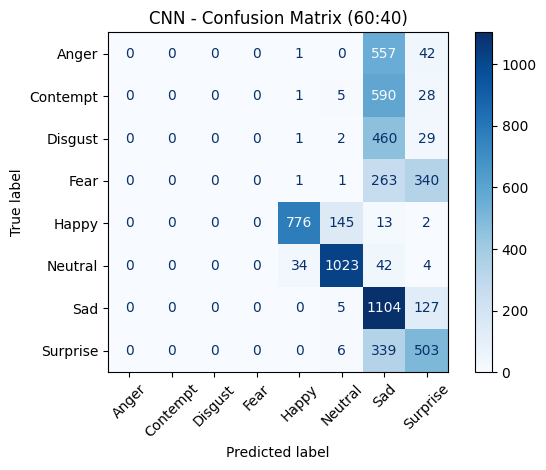

<Figure size 800x800 with 0 Axes>

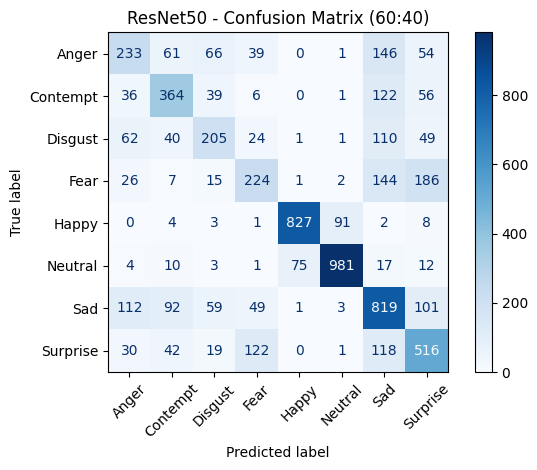

<Figure size 800x800 with 0 Axes>

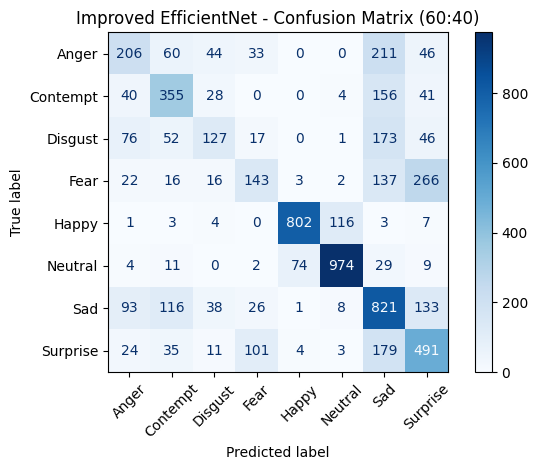

<Figure size 800x800 with 0 Axes>

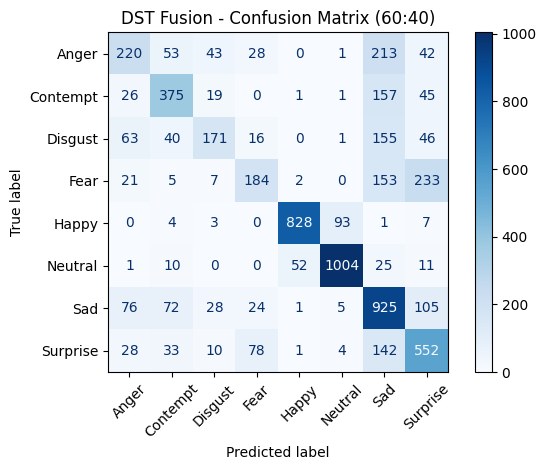

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================================================
# Emotion Labels
# =========================================================

emotion_labels = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================================================
# Plot Function
# =========================================================

def plot_confusion_matrix(true_labels, predictions, title):

    cm = confusion_matrix(true_labels, predictions)

    plt.figure(figsize=(8,8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=emotion_labels
    )

    disp.plot(
        cmap="Blues",
        xticks_rotation=45,
        values_format="d"
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

# =========================================================
# CNN
# =========================================================

plot_confusion_matrix(
    cnn_true_affect_60_40,
    cnn_preds_affect_60_40,
    "CNN - Confusion Matrix (60:40)"
)

# =========================================================
# ResNet50
# =========================================================

plot_confusion_matrix(
    resnet_true_affect_60_40,
    resnet_preds_affect_60_40,
    "ResNet50 - Confusion Matrix (60:40)"
)

# =========================================================
# Improved EfficientNet
# =========================================================

plot_confusion_matrix(
    efficient_true_affect_60_40,
    efficient_preds_affect_60_40,
    "Improved EfficientNet - Confusion Matrix (60:40)"
)

# =========================================================
# DST (CNN + ResNet50 + EfficientNet)
# =========================================================

plot_confusion_matrix(
    cnn_true_affect_60_40,
    all_dst_pred,
    "DST Fusion - Confusion Matrix (60:40)"
)

In [32]:
from sklearn.metrics import classification_report

# =========================================================
# Emotion Labels
# =========================================================

emotion_labels = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================================================
# CNN Classification Report
# =========================================================

print("=" * 80)
print("CNN CLASSIFICATION REPORT (60:40)")
print("=" * 80)

print(
    classification_report(
        cnn_true_affect_60_40,
        cnn_preds_affect_60_40,
        target_names=emotion_labels,
        digits=4
    )
)

# =========================================================
# ResNet50 Classification Report
# =========================================================

print("=" * 80)
print("RESNET50 CLASSIFICATION REPORT (60:40)")
print("=" * 80)

print(
    classification_report(
        resnet_true_affect_60_40,
        resnet_preds_affect_60_40,
        target_names=emotion_labels,
        digits=4
    )
)

# =========================================================
# Improved EfficientNet Classification Report
# =========================================================

print("=" * 80)
print("IMPROVED EFFICIENTNET CLASSIFICATION REPORT (60:40)")
print("=" * 80)

print(
    classification_report(
        efficient_true_affect_60_40,
        efficient_preds_affect_60_40,
        target_names=emotion_labels,
        digits=4
    )
)

# =========================================================
# DST Fusion Classification Report
# =========================================================

print("=" * 80)
print("CNN + RESNET50 + IMPROVED EFFICIENTNET (DST)")
print("=" * 80)

print(
    classification_report(
        cnn_true_affect_60_40,
        all_dst_pred,
        target_names=emotion_labels,
        digits=4
    )
)

CNN CLASSIFICATION REPORT (60:40)
              precision    recall  f1-score   support

       Anger     0.0000    0.0000    0.0000       600
    Contempt     0.0000    0.0000    0.0000       624
     Disgust     0.0000    0.0000    0.0000       492
        Fear     0.0000    0.0000    0.0000       605
       Happy     0.9533    0.8291    0.8869       936
     Neutral     0.8618    0.9275    0.8934      1103
         Sad     0.3278    0.8932    0.4796      1236
    Surprise     0.4679    0.5932    0.5231       848

    accuracy                         0.5286      6444
   macro avg     0.3264    0.4054    0.3479      6444
weighted avg     0.4104    0.5286    0.4426      6444

RESNET50 CLASSIFICATION REPORT (60:40)
              precision    recall  f1-score   support

       Anger     0.4632    0.3883    0.4225       600
    Contempt     0.5871    0.5833    0.5852       624
     Disgust     0.5012    0.4167    0.4550       492
        Fear     0.4807    0.3702    0.4183       605
     

In [36]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/working/best_cnn_affectnet_60_40.pth
/kaggle/working/best_resnet50_affectnet_60_40.pth
/kaggle/working/best_efficientnet_affectnet_60_40.pth
/kaggle/working/.virtual_documents/__notebook_source__.ipynb


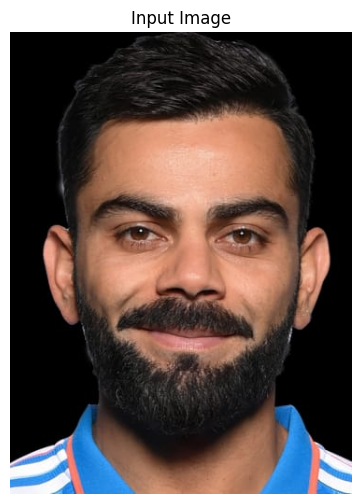

AttributeError: 'Flatten' object has no attribute 'in_features'

In [39]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# =========================================================
# Emotion Labels
# =========================================================

emotion_labels = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================================================
# External Image
# =========================================================

image_path = "/kaggle/input/datasets/soumyamal/hap-photo/hap.jpg.jpeg"

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

# =========================================================
# Automatically Detect CNN Input Size
# =========================================================

fc_features = cnn_model_affect_60_40.classifier[0].in_features

if fc_features == 2304:
    cnn_size = 48
elif fc_features == 4096:
    cnn_size = 64
elif fc_features == 9216:
    cnn_size = 96
elif fc_features == 16384:
    cnn_size = 128
else:
    cnn_size = 96

print(f"CNN Input Size Detected : {cnn_size}x{cnn_size}")

# =========================================================
# Transforms
# =========================================================

cnn_transform = transforms.Compose([
    transforms.Resize((cnn_size, cnn_size)),
    transforms.ToTensor()
])

large_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

cnn_input = cnn_transform(image).unsqueeze(0).to(device)
large_input = large_transform(image).unsqueeze(0).to(device)

# =========================================================
# Evaluation Mode
# =========================================================

cnn_model_affect_60_40.eval()
resnet_model_affect_60_40.eval()
efficientnet_model_affect_60_40.eval()

# =========================================================
# Prediction Function
# =========================================================

def predict(model, img):

    with torch.no_grad():

        output = model(img)

        probs = F.softmax(output, dim=1)

    return probs.cpu().numpy()[0]

# =========================================================
# Predictions
# =========================================================

cnn_probs = predict(cnn_model_affect_60_40, cnn_input)

resnet_probs = predict(resnet_model_affect_60_40, large_input)

efficient_probs = predict(efficientnet_model_affect_60_40, large_input)

# =========================================================
# DST Fusion
# =========================================================

def dst_combine_three(m1, m2, m3):

    m = m1 * m2
    m = m / m.sum()

    m = m * m3
    m = m / m.sum()

    return m

dst_probs = dst_combine_three(
    cnn_probs,
    resnet_probs,
    efficient_probs
)

# =========================================================
# Print Function
# =========================================================

def print_prediction(title, probs):

    print("\n" + "="*65)
    print(title)
    print("="*65)

    for emotion, prob in zip(emotion_labels, probs):
        print(f"{emotion:<12}: {prob:.4f}")

    print("\nPrediction :", emotion_labels[np.argmax(probs)])

# =========================================================
# Results
# =========================================================

print_prediction("CNN", cnn_probs)

print_prediction("ResNet50", resnet_probs)

print_prediction("Improved EfficientNet", efficient_probs)

print_prediction("DST Fusion", dst_probs)

In [40]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms

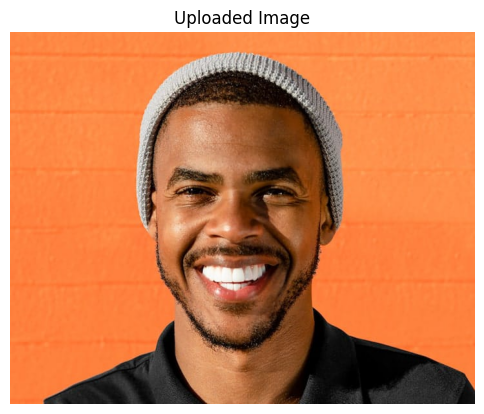

Image Loaded Successfully!
Image Size : (720, 576)


In [54]:
# =========================================================
# Step 2: Load External Image
# =========================================================

image_path = "/kaggle/input/datasets/soumyamal/hii-photo/hi.jpg.jpeg"

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

print("Image Loaded Successfully!")
print("Image Size :", image.size)

In [55]:
# =========================================================
# Step 3: Set Models to Evaluation Mode
# =========================================================

cnn_model_affect_60_40.eval()
resnet_model_affect_60_40.eval()
efficientnet_model_affect_60_40.eval()

print("✓ CNN Model Ready")
print("✓ ResNet50 Model Ready")
print("✓ Improved EfficientNet Model Ready")

print("\nDevice:", device)

✓ CNN Model Ready
✓ ResNet50 Model Ready
✓ Improved EfficientNet Model Ready

Device: cuda


In [58]:
# =========================================================
# Step 4: Image Transforms
# =========================================================

from torchvision import transforms

# ---------- CNN Transform ----------
cnn_transform = transforms.Compose([
    transforms.Resize((96, 96)),      # <-- Change only if your CNN was trained with another size
    transforms.ToTensor()
])

# ---------- ResNet50 & EfficientNet Transform ----------
large_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✓ CNN Transform Created")
print("✓ ResNet50 Transform Created")
print("✓ EfficientNet Transform Created")

✓ CNN Transform Created
✓ ResNet50 Transform Created
✓ EfficientNet Transform Created


In [59]:
# =========================================================
# Step 5: Preprocess Image
# =========================================================

# CNN Input
cnn_input = cnn_transform(image)
cnn_input = cnn_input.unsqueeze(0).to(device)

# ResNet50 & EfficientNet Input
large_input = large_transform(image)
large_input = large_input.unsqueeze(0).to(device)

print("✓ CNN Input Shape :", cnn_input.shape)
print("✓ ResNet50 Input Shape :", large_input.shape)
print("✓ EfficientNet Input Shape :", large_input.shape)

✓ CNN Input Shape : torch.Size([1, 3, 96, 96])
✓ ResNet50 Input Shape : torch.Size([1, 3, 224, 224])
✓ EfficientNet Input Shape : torch.Size([1, 3, 224, 224])


In [60]:
# =========================================================
# Step 6: CNN Prediction
# =========================================================

emotion_labels = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

cnn_model_affect_60_40.eval()

with torch.no_grad():

    cnn_output = cnn_model_affect_60_40(cnn_input)

    cnn_probs = torch.softmax(cnn_output, dim=1)

cnn_probs = cnn_probs.cpu().numpy()[0]

cnn_prediction = np.argmax(cnn_probs)

print("="*60)
print("CNN Prediction")
print("="*60)

for emotion, prob in zip(emotion_labels, cnn_probs):
    print(f"{emotion:<12}: {prob:.4f}")

print("\nPredicted Emotion :", emotion_labels[cnn_prediction])
print("Confidence        :", f"{cnn_probs[cnn_prediction]*100:.2f}%")

CNN Prediction
Anger       : 0.1860
Contempt    : 0.1287
Disgust     : 0.1419
Fear        : 0.0880
Happy       : 0.0034
Neutral     : 0.0101
Sad         : 0.3629
Surprise    : 0.0789

Predicted Emotion : Sad
Confidence        : 36.29%


In [61]:
import numpy as np
import torch
import torch.nn.functional as F

# =========================================================
# Emotion Labels
# =========================================================

emotion_labels = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================================================
# Evaluation Mode
# =========================================================

cnn_model_affect_60_40.eval()
resnet_model_affect_60_40.eval()
efficientnet_model_affect_60_40.eval()

# =========================================================
# CNN Prediction
# =========================================================

with torch.no_grad():
    cnn_output = cnn_model_affect_60_40(cnn_input)
    cnn_probs = F.softmax(cnn_output, dim=1).cpu().numpy()[0]

# =========================================================
# ResNet50 Prediction
# =========================================================

with torch.no_grad():
    resnet_output = resnet_model_affect_60_40(large_input)
    resnet_probs = F.softmax(resnet_output, dim=1).cpu().numpy()[0]

# =========================================================
# EfficientNet Prediction
# =========================================================

with torch.no_grad():
    eff_output = efficientnet_model_affect_60_40(large_input)
    eff_probs = F.softmax(eff_output, dim=1).cpu().numpy()[0]

# =========================================================
# DST Fusion
# =========================================================

# If you already have dst_combine_three() defined,
# comment out this function.

def dst_combine_three(cnn, resnet, eff):
    fused = cnn * resnet * eff
    fused = fused / fused.sum()
    return fused

dst_probs = dst_combine_three(
    cnn_probs,
    resnet_probs,
    eff_probs
)

# =========================================================
# Display Function
# =========================================================

def display_result(title, probs):

    print("\n" + "="*70)
    print(title)
    print("="*70)

    for emotion, prob in zip(emotion_labels, probs):
        print(f"{emotion:<12} : {prob:.4f}")

    pred = np.argmax(probs)

    print("\nPrediction :", emotion_labels[pred])
    print(f"Confidence : {probs[pred]*100:.2f}%")

# =========================================================
# Print Results
# =========================================================

display_result("CNN", cnn_probs)

display_result("ResNet50", resnet_probs)

display_result("Improved EfficientNet", eff_probs)

display_result("DST Fusion", dst_probs)


CNN
Anger        : 0.1860
Contempt     : 0.1287
Disgust      : 0.1419
Fear         : 0.0880
Happy        : 0.0034
Neutral      : 0.0101
Sad          : 0.3629
Surprise     : 0.0789

Prediction : Sad
Confidence : 36.29%

ResNet50
Anger        : 0.5209
Contempt     : 0.0206
Disgust      : 0.0735
Fear         : 0.1018
Happy        : 0.0002
Neutral      : 0.0147
Sad          : 0.2614
Surprise     : 0.0068

Prediction : Anger
Confidence : 52.09%

Improved EfficientNet
Anger        : 0.0751
Contempt     : 0.0377
Disgust      : 0.0950
Fear         : 0.1867
Happy        : 0.0021
Neutral      : 0.0033
Sad          : 0.3553
Surprise     : 0.2448

Prediction : Sad
Confidence : 35.53%

DST Fusion
Anger        : 0.1658
Contempt     : 0.0023
Disgust      : 0.0226
Fear         : 0.0381
Happy        : 0.0000
Neutral      : 0.0000
Sad          : 0.7682
Surprise     : 0.0030

Prediction : Sad
Confidence : 76.82%


In [49]:
# =========================================================
# DST Fusion Predictions
# =========================================================

def dst_fusion(prob1, prob2):
    fused = prob1 * prob2
    fused = fused / np.sum(fused)
    return fused

# CNN + ResNet50
cnn_resnet_dst = dst_fusion(cnn_probs, resnet_probs)

# CNN + EfficientNet
cnn_eff_dst = dst_fusion(cnn_probs, eff_probs)

# ResNet50 + EfficientNet
resnet_eff_dst = dst_fusion(resnet_probs, eff_probs)

# CNN + ResNet50 + EfficientNet
cnn_resnet_eff_dst = dst_fusion(cnn_resnet_dst, eff_probs)

# =========================================================
# Final Predictions
# =========================================================

print("\n" + "="*65)
print("FINAL DST PREDICTIONS")
print("="*65)

print(f"CNN + ResNet50 DST           : {emotion_labels[np.argmax(cnn_resnet_dst)]}")

print(f"CNN + EfficientNet DST       : {emotion_labels[np.argmax(cnn_eff_dst)]}")

print(f"ResNet50 + EfficientNet DST  : {emotion_labels[np.argmax(resnet_eff_dst)]}")

print(f"CNN + ResNet50 + EfficientNet DST : {emotion_labels[np.argmax(cnn_resnet_eff_dst)]}")


FINAL DST PREDICTIONS
CNN + ResNet50 DST           : Anger
CNN + EfficientNet DST       : Anger
ResNet50 + EfficientNet DST  : Anger
CNN + ResNet50 + EfficientNet DST : Anger


In [62]:
# =========================================================
# FINAL PREDICTIONS
# =========================================================

print("\n" + "="*65)
print("FINAL PREDICTIONS")
print("="*65)

print(f"CNN Prediction                     : {emotion_labels[np.argmax(cnn_probs)]}")

print(f"ResNet50 Prediction                : {emotion_labels[np.argmax(resnet_probs)]}")

print(f"Improved EfficientNet Prediction   : {emotion_labels[np.argmax(eff_probs)]}")

print()

print(f"CNN + ResNet50 DST                : {emotion_labels[np.argmax(cnn_resnet_dst)]}")

print(f"CNN + EfficientNet DST            : {emotion_labels[np.argmax(cnn_eff_dst)]}")

print(f"ResNet50 + EfficientNet DST       : {emotion_labels[np.argmax(resnet_eff_dst)]}")

print(f"CNN + ResNet50 + EfficientNet DST : {emotion_labels[np.argmax(cnn_resnet_eff_dst)]}")


FINAL PREDICTIONS
CNN Prediction                     : Sad
ResNet50 Prediction                : Anger
Improved EfficientNet Prediction   : Sad

CNN + ResNet50 DST                : Anger
CNN + EfficientNet DST            : Anger
ResNet50 + EfficientNet DST       : Anger
CNN + ResNet50 + EfficientNet DST : Anger
